In [5]:
# datasetgen.ipynb
# 02/Apr/2026

# Genera un dataset con 1.000.000 muestras (datos) linealmente separables  
# Cada dato está etiquetado, indicando a qué conjunto pertenece                   
# Guarda los datos en disco, con algún formato del libro Python Crash Course  
                 
# Tipo de datos (dtype) float32, para mayor claridad y simplicidad del código
# Training set (75% of data). Se usa para entrenar el modelo
# Validation set (15%). Para ajustar los hyperparameters (number of layers), monitorizar el overfitting y parar el aprendizaje cuando la pérdida deja de mejorar
# Test set (15%). Touched only once, at the very end, to give an unbiased estimate of final model performance. 

import os
import numpy as np
import matplotlib.pyplot as plt

# Número de muestras en cada parte del dataset
NUM_TRAIN_SAMPLES = 750
NUM_VAL_SAMPLES = 150
NUM_TEST_SAMPLES = 150

# Constants for range
MAX_RAN = 100
MIN_RAN = -100

# Genero las muestras y etiquetas de entrenamiento usando NumPY Vectorized Operations = calcular todos los valores a la vez

# Genero una matriz de NUM_TRAIN_SAMPLES filas y 2 columnas
# 1. Generate values between 0 and 1
# 2. Multiply by 200 (makes range 0 to 200)
# 3. Subtract 100 (makes range -100 to 100)
train_data = np.random.rand(NUM_TRAIN_SAMPLES, 2).astype(np.float32) * (MAX_RAN - MIN_RAN) + MIN_RAN

# 2. Extract x and y columns
x = train_data[:, 0]   # Todos los valores de x
y = train_data[:, 1]   # Todos los valores de y

# 3. Define the line: y_line = 2*x - 5
# Logic: If (y < 2*x - 5) → 1 (Right), else 0 (Left)
train_labels = (y < (2 * x - 25)).astype(np.float32)

# Genero las muestras y etiquetas de validación
validation_data = np.random.rand(NUM_VAL_SAMPLES, 2).astype(np.float32) * (MAX_RAN - MIN_RAN) + MIN_RAN
x = validation_data[:, 0]   # Todos los valores de x
y = validation_data[:, 1]   # Todos los valores de y
validation_labels = (y < (2 * x - 25)).astype(np.float32)

# Genero las muestras y etiquetas de test
test_data = np.random.rand(NUM_TEST_SAMPLES, 2).astype(np.float32) * (MAX_RAN - MIN_RAN) + MIN_RAN
x = test_data[:, 0]   # Todos los valores de x
y = test_data[:, 1]   # Todos los valores de y
test_labels = (y < (2 * x - 25)).astype(np.float32)


In [9]:



# Show the first 5 entries to verify
print("\nFirst 5 (x, y) couples and their labels (0=Left, 1=Right):")
for i in range(5):
    print(f"Point: {train_data[i].tolist()} -> Label: {train_labels[i].item()}")


First 5 (x, y) couples and their labels (0=Left, 1=Right):
Point: [93.09112548828125, 10.616920471191406] -> Label: 1.0
Point: [15.278396606445312, -27.73163604736328] -> Label: 1.0
Point: [-10.149246215820312, -79.29515075683594] -> Label: 1.0
Point: [21.858741760253906, 23.814727783203125] -> Label: 0.0
Point: [9.045921325683594, -91.50991821289062] -> Label: 1.0


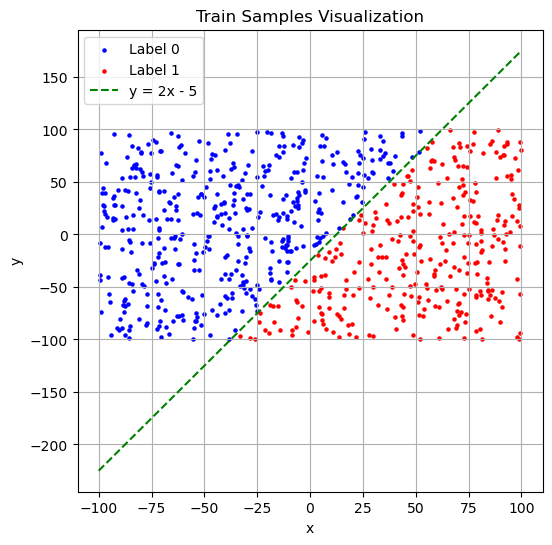

In [3]:

x = train_data[:, 0]
y = train_data[:, 1]

# Convert labels to boolean masks
mask_0 = train_labels == 0
mask_1 = train_labels == 1

# Plot points with different colors
plt.figure(figsize=(6, 6))
plt.scatter(x[mask_0], y[mask_0], color='blue', s=5, label='Label 0')
plt.scatter(x[mask_1], y[mask_1], color='red', s=5, label='Label 1')

# Optional: plot the decision boundary y = 2x - 5
x_line = np.linspace(-100, 100, 100)
y_line = 2 * x_line - 25
plt.plot(x_line, y_line, color='green', linestyle='--', label='y = 2x - 5')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Train Samples Visualization")
plt.legend()
plt.grid(True)

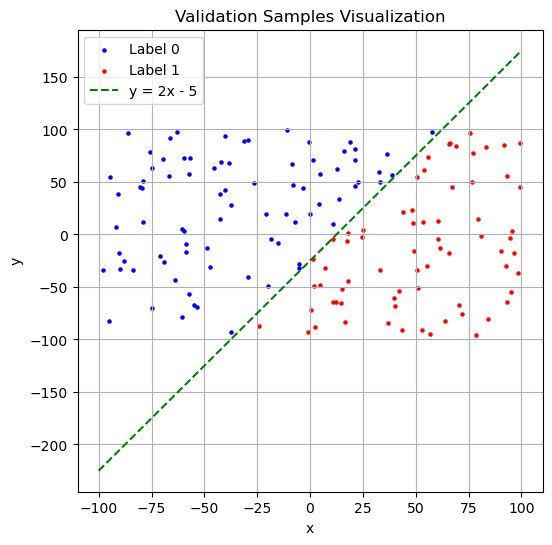

In [6]:
x = validation_data[:, 0]
y = validation_data[:, 1]

# Convert labels to boolean masks
mask_0 = validation_labels == 0
mask_1 = validation_labels == 1

# Plot points with different colors
plt.figure(figsize=(6, 6))
plt.scatter(x[mask_0], y[mask_0], color='blue', s=5, label='Label 0')
plt.scatter(x[mask_1], y[mask_1], color='red', s=5, label='Label 1')

# Optional: plot the decision boundary y = 2x - 5
x_line = np.linspace(-100, 100, 100)
y_line = 2 * x_line - 25
plt.plot(x_line, y_line, color='green', linestyle='--', label='y = 2x - 5')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Validation Samples Visualization")
plt.legend()
plt.grid(True)

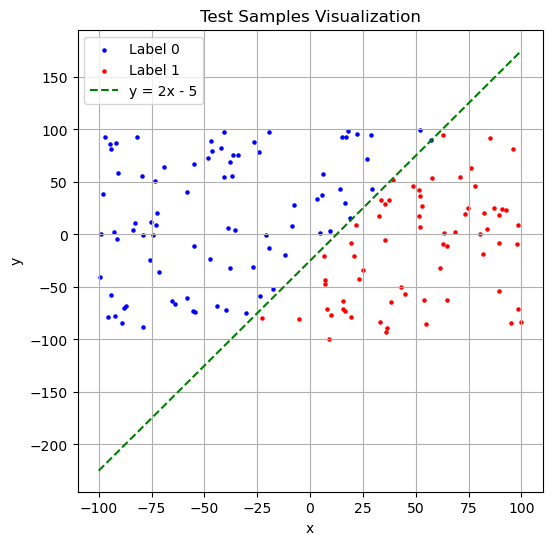

In [7]:
x = test_data[:, 0]
y = test_data[:, 1]

# Convert labels to boolean masks
mask_0 = test_labels == 0
mask_1 = test_labels == 1

# Plot points with different colors
plt.figure(figsize=(6, 6))
plt.scatter(x[mask_0], y[mask_0], color='blue', s=5, label='Label 0')
plt.scatter(x[mask_1], y[mask_1], color='red', s=5, label='Label 1')

# Optional: plot the decision boundary y = 2x - 5
x_line = np.linspace(-100, 100, 100)
y_line = 2 * x_line - 25
plt.plot(x_line, y_line, color='green', linestyle='--', label='y = 2x - 5')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Test Samples Visualization")
plt.legend()
plt.grid(True)